# Classification I - Support Vector Machines
In this exercise, you will perform a simple land cover classification using Support Vector Machines. We picked a study site in Iraq and are going to use imagery from Landsat 8. For this exercise you need to create some training data. You can use a GIS software like QGIS for this. (If you don't have it, you might just use the data we provide, but it is much better to run it with your own training samples as well.)

We are going to compare our results to the land cover map offered by [Copernicus Global Land Service](https://land.copernicus.eu/global/products/lc).


#### Target land use and land cover definitions

* 0 = `NoData` (This only applies for our training set. We didn't collect a training label for this pixel.)
* 1 = `built-up` (This includes buildings and paved surfaces such as roads, public spaces, etc.)
* 2 = `water` (This includes lakes and rivers.)
* 3 = `vegetation` (This includes farmland, forests and public green space.)
* 4 = `other`


#### Context

_"The so-called Islamic State (IS) has used water as a weapon in order to further its political and military aims in Syria and Iraq. In this water-scarce region, IS has retained water and cut off crucial supplies, flooded large areas as well as contaminated resources. The capture of large dams in the Euphrates and Tigris basin has made it possible to deploy the water weapon even more effectively and in a frequent, systematic, consistent and flexible manner."_

A simple land cover classification is a basic step towards quantifying the effect of water shortage by monitoring which areas are covered by vegetation and water. In our exercise, we are only considering a single timestamp and are not going to look into a change detection analysis (at least not yet). But still, it should give you a first idea on how you can perform such an analysis yourself.

Sources:
* [Von Lossow, T. (2016). The rebirth of water as a weapon: IS in Syria and Iraq. The International Spectator, 51(3), 82-99.](https://www.tandfonline.com/doi/abs/10.1080/03932729.2016.1213063)
* [Tobias von Lossow (2016): "Der IS und das Wasser"](https://monde-diplomatique.de/artikel/!5274581)

#### General notes:
For each step we tried to add some hints on the modules to use. However, bear in mind that there are always many more ways that lead to the same solution than the options we had in mind. So be confident enough to go with "your" solution.

You need at least following python libraries:
* numpy
* pandas
* rasterio
* `svm, confusion_matrix` and `classification_report` from sklearn
* matplotlib.pyplot and `LinearSegmentedColormap` from matplotlib.colors

In [15]:
import numpy as np
import pandas as pd
import rasterio as rio
from sklearn import svm
from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


In [16]:
## uncomment following code
## we define a custom colormap for matplotlib here
colors = [(1, 1, 1), (0.8, 0.8, 0.8), (0.25, 0.25, 1), (0, 1, 0), (1, 1, 0.75)]
n_bins = [0, 1, 2, 3, 4]  # Discretizes the interpolation into bins
cmap_name = "landcover"
landcover_colormap = LinearSegmentedColormap.from_list(cmap_name, colors, N=5)

## Download the data
Download the zip file `02_data.zip` from this [folder](https://tubcloud.tu-berlin.de/s/ZX6LbyAQzC5i6RL).
Unzip the folder and place it in a folder called `./data` in the same directory of this exercise.


## 1. Load and display Landsat data.
SVM is a pixel-based classifier and does not consider the neighbourhood of a pixel. Thus, it's just enough to list all pixel disregarding geography.

* Load the individual tif files (starting with `LC81690372015188LGN00_`)  into an array. Only consider the following bands: ["B2", "B3", "B4", "B5", "B6", "B7"]
* What is the shape (number of columns and rows)?
* When using classifiers in `scikit-learn` you have to reshape your data, e.g. into a dataframe. Each pixel should refer to a row in a dataframe which holds the values from the raster band as attributes.
* What is the spatial resolution of the available data?
* Optional: Have a more in depth data exploration in a GIS such as QGIS.


In [17]:
## load raster bands and add to numpy array band


# Approach using rasterio:
def raster_to_array(filename):
    with rio.open(filename, "r") as src:
        array = src.read(1)  # 2D array of the band
        return array


bands = ["B2", "B3", "B4", "B5", "B6", "B7"]
data = []
for b in bands:
    filename = f"./data/LC81690372015188LGN00_{b}.TIF"
    array = raster_to_array(filename)
    data.append(array)

# convert list into a 3D-array
data = np.array(data)
print(data.shape)  # shape of the dataset - 6 layers, 1960 rows, 3832 columns

# Reshape your data
samples = data.reshape((len(bands), -1)).T
samples_df = pd.DataFrame(samples, columns=bands)
print(samples_df.tail())

## spatial resolution: either use QGIS or read the metadata from one of the rasters
with rio.open(filename, "r") as src:
  print(src.crs)  # EPSG: 32638 -> geodetic CRS and thus spatail resolution are meters
  print(src.transform)  # get spatial resolution

(6, 1960, 3832)
            B2     B3     B4     B5     B6     B7
7510715  12732  13292  14371  18737  18124  15439
7510716  13026  13644  15057  19031  18594  16537
7510717  13475  14488  16064  19469  20141  18126
7510718  13607  14426  16142  19510  20113  18036
7510719  13332  14157  15726  19746  20425  18182
EPSG:32638
| 30.00, 0.00, 337905.00|
| 0.00,-30.00, 3722835.00|
| 0.00, 0.00, 1.00|


**Large raster data and parallel processing**\
Just keep in mind that `gdal` and `rasterio` are just two packages for handling raster data, but of course various alternatives exist (here we are just using `rasterio` as `gdal` is tricky to install). In case of handling large raster data (`netCDF, TIF`) or if you want to do parallel processing you might have a look at `xarray`, `rioxarray` (combination of `xarray` and `rasterio`) and `geocube`(combination of `xarray`and `geopandas`). Packages based on `xarray` are more common in Computer and Climate Science, but in my opinion they have some nice benefits - e.g. efficiency in regard to very large rasters (e.g. "lazy loading"), handling of multi-dimensional data (often needed for `netCDF` files), easy assess of metadata and quite Pythonic

In [18]:
# Example for rioxarray
!uv add rioxarray

Resolved 150 packages in 0.49ms
Audited 145 packages in 1ms


In [19]:

import rioxarray as rxr

scene = rxr.open_rasterio(filename)
print(scene.rio.crs)  # CRS
print(scene.rio.resolution())  # spatial resoltion
scene

EPSG:32638
(30.0, -30.0)


<xarray.DataArray (band: 1, y: 1960, x: 3832)> Size: 15MB
[7510720 values with dtype=uint16]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 16kB 3.723e+06 3.723e+06 ... 3.664e+06 3.664e+06
  * x            (x) float64 31kB 3.379e+05 3.38e+05 ... 4.528e+05 4.528e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Point
    scale_factor:   1.0
    add_offset:     0.0

## 2. Load and prepare training set
* Load the raster `training_samples_utm38` into an array. Plot an image of the training samples array using `matplotlib`.
* Add the values as a new column (e.g. as `training_label` or `y_train`) to your dataframe. Again make sure to reshape your data.
* Then, create a new dataframe for the training samples using `pandas`. All instances for which the `training_label` **isn't** set to `0` should belong to the training set.
* How many training samples are there for each class? **Hint:** For class 2 this would be, for instance, 114690 samples

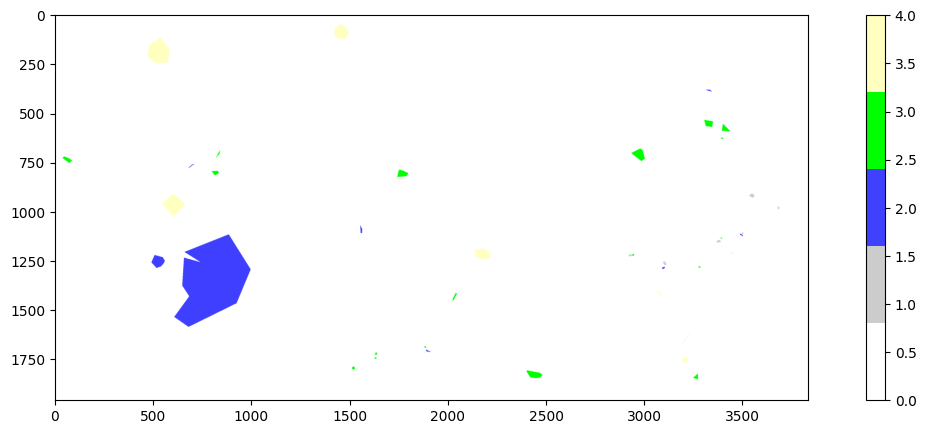

      B2     B3     B4     B5     B6     B7  training_label
0  16471  19396  23884  27562  29219  25790               0
1  16534  19381  23748  27470  28980  25624               0
2  15932  18711  22812  26740  27862  23978               0
3  13979  16094  20160  25413  25520  19406               0
4  14129  16182  20353  25908  25404  19131               0
training_label
2    114690
4     25579
3     10497
1      1125
Name: count, dtype: int64


In [20]:
# load training samples
array = raster_to_array("./data/training_samples_utm38N.tif")

# plot training samples
plt.figure(figsize=(15, 5))
plt.imshow(array, cmap=landcover_colormap, vmin=0, vmax=4)
plt.colorbar()
plt.show()

# add training labels to dataframe
training_samples = array.flatten()  # since we have only one band here we can use flatten() and not reshape().T
samples_df["training_label"] = pd.Series(training_samples)
print(samples_df.head())

# get training data
training_df = samples_df.loc[samples_df["training_label"] > 0]

# number of training samples per class
print(training_df["training_label"].value_counts())

## 3. Train your model and predict classes for testing set
* Train a Support Vector Machine using the `svm` module of `sklearn`. For the sake of getting results quicker let's choose the `LinearSVC` classifier. Apply it on your dataframe with the training_labels
* Apply your model and predict the classes for all samples. Add the lables used fro training (i.e. `training_label` or `y_train`) and the predicted labels  (i.e. `predicted_label` or `y_pred`) to the dataframe


In [21]:
# train classifier
X_train = training_df[bands]
y_train = training_df["training_label"]
clf = svm.LinearSVC()
clf.fit(X_train, y_train)

# predict
samples_df["prediction_label"] = clf.predict(samples_df[bands])
print(samples_df.tail())

            B2     B3     B4     B5     B6     B7  training_label  \
7510715  12732  13292  14371  18737  18124  15439               0   
7510716  13026  13644  15057  19031  18594  16537               0   
7510717  13475  14488  16064  19469  20141  18126               0   
7510718  13607  14426  16142  19510  20113  18036               0   
7510719  13332  14157  15726  19746  20425  18182               0   

         prediction_label  
7510715                 3  
7510716                 3  
7510717                 3  
7510718                 3  
7510719                 3  


## 4. Display your classification result.
* Again you have to reshape your data. This time back into a two-dimensional array. Use the dimensions you got from the very beginning (number of columns and rows: `cols = 1960, rows = 3832`).
* Plot your classification results array as an image using `matplotlib`.
* What is your first impression regarding the classifier's accuracy?

Optional:
* Save your array into a tif and inspect it further in QGIS.

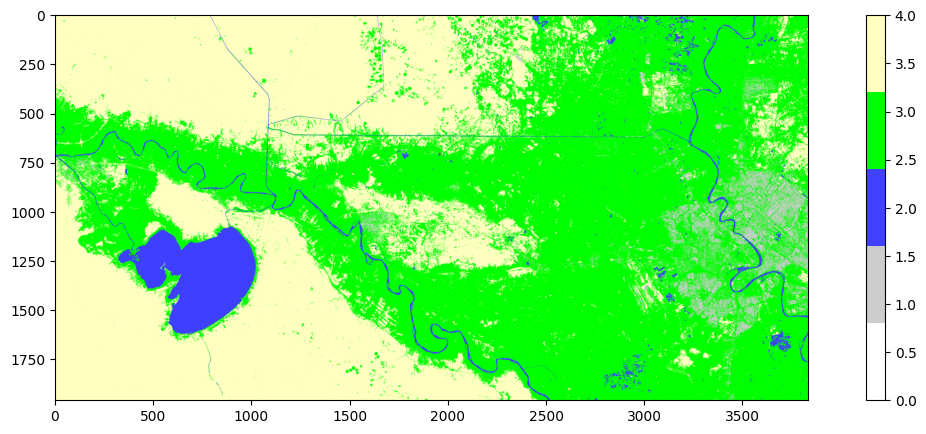

In [22]:
# Reshape pandas series into numpy array
cols = 1960
rows = 3832
classification_array = np.array(samples_df["prediction_label"]).reshape((cols, rows))

# Plot your classification result
plt.figure(figsize=(15, 5))
plt.imshow(classification_array, cmap=landcover_colormap, vmin=0)  # set vmin=0 here, so that the colors match
plt.colorbar()
plt.show()

**First impression**
By comparing the original remote sensing scences with the above prediction, we see that the classifier less captures built-up areas (grey class)


In [23]:
## Approach with rasterio:

def array2raster(outfile_name, raster_extent, pixel_width, pixel_height, epsg, array):
  with rio.open(
    outfile_name, "w", driver="GTiff",
    width=pixel_width, height=pixel_height,
    count=1, dtype=classification_array.dtype,
    crs=f"EPSG:{epsg}",
    transform=rio.transform.from_origin(
        raster_extent[0], raster_extent[1],
        pixel_width, pixel_height
    )
  ) as dst:
    dst.write(classification_array, 1)

## print metadata needed to write out raster as tif
with rio.open("./data/LC81690372015188LGN00_B2.TIF", "r") as src:
    print(src.profile["transform"], "\n", src.profile["crs"])


## save as tif
outfile_name = "classification_result_rio.tif"
epsg = 32638
raster_extent = [337905.0, 3722835.0]
pixel_width, pixel_height = 30, 30  # meters

array2raster(outfile_name, raster_extent, pixel_width, pixel_height, epsg, classification_array)

| 30.00, 0.00, 337905.00|
| 0.00,-30.00, 3722835.00|
| 0.00, 0.00, 1.00| 
 EPSG:32638


## 5. Assess the accuracy of your classification
* Load the test set (ie. validation samples: `validation_samples_utm38N.tif`) and add it to the dataframe as a new column. Keep in mind to transform the raster before adding it to the dataframe.
* You have to reclassify the data, since it has more classes than our dataset. You can use the following dictionary and `pandas`' `replace` function:
    ```
    reclass_dict = {
        20: 3,   # shrubs --> vegetation
        30: 3,   # Herbaceous vegetation --> vegetation
        40: 3,   # cropland --> vegetation
        50: 1,   # Urban / built up --> built-up
        60: 4,   # bare / sparse vegetation --> other
        80: 2,   # permanent water bodies --> water
        90: 2,   # Herbaceous wetland --> water
        116: 3,  # closed forest --> vegetation
        121: 3,  # open forest, evergreen --> vegetation
        126: 3,  # open forest, unknown --> vegetation
    }
    ```
* Calculate and display a confusion matrix. **Hint:** Make sure to consider only the non-training samples in this step, e.g. via `testing_df = samples_df.loc[samples_df["training_label"] == 0]`
* Describe the performance of the classifier on the validation set (also known as test set). Which classes tend to be problematic?

In [24]:
# load validation samples and add to dataframe
array = raster_to_array("data/validation_samples_utm38N.tif")
validation_samples = array.flatten()  # since we have only one band here we can use flatten() and not reshape().T
samples_df["validation_label_raw"] = pd.Series(validation_samples)

# reclassify using dictionary
reclass_dict = {
    20: 3,  # shrubs --> vegetation
    30: 3,  # Herbaceous vegetation --> vegetation
    40: 3,  # cropland --> vegetation
    50: 1,  # Urban / built up --> built-up
    60: 4,  # bare / sparse vegetation --> other
    80: 2,  # permanent water bodies --> water
    90: 2,  # Herbaceous wetland --> water
    116: 3,  # closed forest --> vegetation
    121: 3,  # open forest, evergreen --> vegetation
    126: 3,  # open forest, unknown --> vegetation
}
samples_df["validation_label"] = samples_df["validation_label_raw"].replace(reclass_dict)
print(samples_df.shape)

# select only test samples
testing_df = samples_df.loc[samples_df["training_label"] == 0]
print(testing_df.shape)


(7510720, 10)
(7358829, 10)


In [25]:
# get confusion matrix
cm = confusion_matrix(testing_df["validation_label"], testing_df["prediction_label"])
print(cm)

[[ 186226    1606  333560   24431]
 [     91  114712    6300     191]
 [  18586   69237 3307563  796834]
 [  25882   15417  208027 2250166]]


In [26]:
# assess predictive performance of the classifier
report = classification_report(testing_df["validation_label"], testing_df["prediction_label"])
print(report)

              precision    recall  f1-score   support

           1       0.81      0.34      0.48    545823
           2       0.57      0.95      0.71    121294
           3       0.86      0.79      0.82   4192220
           4       0.73      0.90      0.81   2499492

    accuracy                           0.80   7358829
   macro avg       0.74      0.74      0.71   7358829
weighted avg       0.81      0.80      0.79   7358829



**Answer to "Describe the performance of the classifier. Which classes tend to be problematic?"**

We see that built-up areas are less well detected by the classifier indicated by a low class recall and f1-score. They underpin our initial impression from Task 4. Furthermore, the report indicates that the classifier performed quite well in the other classes, however, the performance on the class for water bodies could also be further improved.\
The overall performance of the classifier can be assessed by macro- and weighted-averaged performance scores (last two rows in the classification report). The frequency (i.e. number of datapoints of each class) is shown in the "support" column
- Macro averaging is suitable to assess performance on (slightly) imbalanced datasets, since the arithmetic mean is used as weight for each class (e.g. all class recall scores get the same weight - here: `macro-avg. recall = 0.25*0.34 + 0.25*0.95 + 0.25*0.79 + 0.25*0.90`). By this approach, less frequent classes (and thus usually harder to predict) have the same impact on the performance score as frequent classes.
- On the other hand, the class weights used in weighted-averaged scores are defining by the relative class sizes; less frequent classes (here: classes 1 and 2) get much smaller weights and thus impact the score much less compared to class 3 and 4. The wrong usage of this measure might cause a strong overestimation of a classifier's performance. In an extreme case a model would just predict every data point as the most frequent class, leading to weighted-avg. scores close to 1.00. However, in such an extreme case also macro averaging wouldn't be a suitable measure ;)



## 6. Iteratively improve training data
* Adjust your training samples. You can do this in QGIS by removing, adjusting and adding polygons to `training_samples_utm38N.shp`
* Once you finished your edits you can run the code below to rasterize the geometries.
* Run the classification again and check the accuracy.
* Could you improve the performance of the classifier?

In [27]:
## If needed install gdal package and its dependencies:

#$ sudo add-apt-repository ppa:ubuntugis/ppa && sudo apt-get update
#$ sudo apt-get update
#$ sudo apt-get install gdal-bin
#$ sudo apt-get install libgdal-dev
#$ export CPLUS_INCLUDE_PATH=/usr/include/gdal
#$ export C_INCLUDE_PATH=/usr/include/gdal

## then close and reopen your terminal/IDE

In [ ]:
%%bash 

gdal_rasterize -l training_samples_utm38N -a class -tr 30 30 -a_nodata 0 -te 337905.0 3664035.0 452865.0 3722835.0 -ot UInt16 -of GTiff data/training_samples_utm38N.shp data/training_samples_utm38N.tif